# AII 600. Math background: OLS, MLE, SGD

Optional. Not submitted. The named videos are a couple of hours. The units add practice if a cell does not make sense yet; a cold pass through every link is closer to half a day. This is not a course in calculus or linear algebra.

The course uses three calculations that sit on the same small stack of math.

- OLS, week 5. $\hat\beta = (X^\top X)^{-1} X^\top y$
- MLE, week 4. $\hat\theta = \arg\max_\theta \sum_i \log p(y_i\mid\theta)$
- SGD, week 12. $\theta \leftarrow \theta - \eta\,\nabla L$

$\sum_i$ means add over the observations. [Sigma notation](https://www.khanacademy.org/math/algebra-home/alg-series/alg-sigma-notation/v/sigma-notation-sum). $\arg\max_\theta$ is the $\theta$ that makes the function largest, not that largest value. $\arg\min$ is the same idea downhill. OLS and ridge are $\arg\min$.

In this course $\log$ means $\ln$, base $e$, and that is what `np.log` computes. A Khan video that writes $\log_4$ or $\log_5$ is teaching the same algebra; we only ever need base $e$. Logs show up three ways: a product of probabilities becomes a sum (week 4), a transform that straightens a power law (weeks 5–6, midterm), and log-odds (week 6, midterm). Week 7 and 9 reuse $\ln$ on wealth and on odds; same function, different sentence.

This notebook is the background for those, with a Khan Academy link for each piece and a short check in Python. Watch, then run the cell. Python kernel. R is allowed: switch the kernel and rewrite.

Skip series, vector spaces, determinants, eigenvalues, and volumes of revolution. You need the definite integral as area, for expected values. Probability as a subject is weeks 1–2; do not prep that here.

Course book: [Polson and Sokolov](https://vsokolov.org/html/_book/). Tutor: [setup](https://vsokolov.org/courses/600.html#course-tutor).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


## 1. Logs. MLE, then a transform

A likelihood is a product, $L(\theta)=\prod_i p(y_i\mid\theta)$. Products of small numbers underflow, and the derivative of a product is messy. $\ln$ turns the product into a sum. The maximizer does not change, because $\ln$ is increasing.

$$
\ell(\theta)=\sum_{i=1}^n \ln p(y_i\mid\theta)
$$

The property you need is $\ln(ab)=\ln a+\ln b$. Also $\ln(a^n)=n\ln a$. `np.log(0.3 * 0.5 * 0.2)` and `np.log(0.3) + np.log(0.5) + np.log(0.2)` are the same number. They are not $\log_{10}$.

The second use is a data transform, weeks 5–6 and the midterm. A power law $y=\beta_0 x^{\beta_1}$ is a curve. Take $\ln$ of both sides:

$$
\ln y = \ln\beta_0 + \beta_1 \ln x.
$$

That is a line in $(\ln x,\ln y)$. The slope $\beta_1$ is an elasticity: the percent change in $y$ per percent change in $x$. A 10% move in $x$ is about a $10\beta_1$% move in $y$. Week 5 runs this on brain and body weight. You cannot log a zero or a dummy.

- Video: [Intro to logarithms](https://www.khanacademy.org/math/algebra2/x2ec2f6f830c9fb89:logs/x2ec2f6f830c9fb89:log-intro/v/logarithms)
- Article: [Properties of logarithms](https://www.khanacademy.org/math/algebra2/x2ec2f6f830c9fb89:logs/x2ec2f6f830c9fb89:log-prop/a/properties-of-logarithms)
- Video: [Using several properties](https://www.khanacademy.org/math/algebra2/x2ec2f6f830c9fb89:logs/x2ec2f6f830c9fb89:log-prop/v/using-multiple-logarithm-properties-to-simplify)
- Video: [Logarithmic scale](https://www.khanacademy.org/math/algebra2/exponential-and-logarithmic-functions/logarithmic-scale/v/vi-and-sal-explore-how-we-think-about-scale)
- Unit, if you want practice: [Algebra 2, logarithms](https://www.khanacademy.org/math/algebra2/x2ec2f6f830c9fb89:logs)


In [2]:
p = np.array([0.3, 0.5, 0.2])
np.log(np.prod(p)), np.sum(np.log(p)), np.log(100)


(np.float64(-3.506557897319982),
 np.float64(-3.506557897319982),
 np.float64(4.605170185988092))

np.float64(0.75)

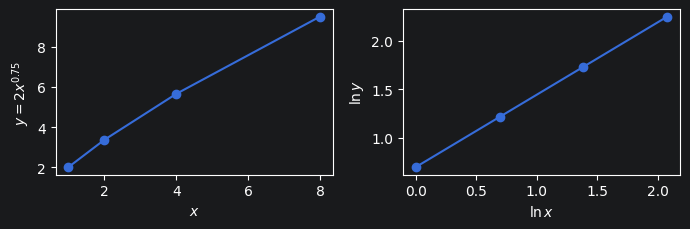

In [3]:
x = np.array([1.0, 2.0, 4.0, 8.0])
y_pow = 2 * x ** 0.75
slope = (np.log(y_pow[-1]) - np.log(y_pow[0])) / (np.log(x[-1]) - np.log(x[0]))

fig, ax = plt.subplots(1, 2, figsize=(7, 2.4))
ax[0].plot(x, y_pow, "o-")
ax[0].set_xlabel("$x$")
ax[0].set_ylabel("$y=2x^{0.75}$")
ax[1].plot(np.log(x), np.log(y_pow), "o-")
ax[1].set_xlabel("$\\ln x$")
ax[1].set_ylabel("$\\ln y$")
fig.tight_layout()
slope


## 2. Derivatives and integrals. MLE, OLS, expected value

Both methods say: write a function of the unknown, differentiate, set the derivative to zero. For a normal mean that function is the residual sum of squares, $\sum_i (y_i-\mu)^2$. The value of $\mu$ that maximizes the log-likelihood is the same value that minimizes the squares. After the plot, the same section is the definite integral as area, which is how the course writes $E[X]$ and a CDF.


You need the idea of a derivative, the power rule, and that a sum differentiates term by term. You do not need a formal $\varepsilon$-$\delta$ limit.

- Unit: [Derivative as a concept](https://www.khanacademy.org/math/calculus-1/cs1-derivatives-definition-and-basic-rules)
- Video: [Power rule](https://www.khanacademy.org/math/calculus-1/cs1-derivatives-definition-and-basic-rules/cs1-power-rule/v/power-rule)
- Video: [Basic derivative rules](https://www.khanacademy.org/math/calculus-1/cs1-derivatives-definition-and-basic-rules/cs1-derivative-rules-constant-sum-difference-and-constant-multiple/v/derivative-properties-and-polynomial-derivatives)

On paper, for $y=(2,3,7)$, write $\mathrm{RSS}(\mu)=(2-\mu)^2+(3-\mu)^2+(7-\mu)^2$, differentiate, set to zero. You should get $\hat\mu=4$, the sample mean. The cell plots that parabola and marks the mean. It does not hunt for the minimum on a grid.


np.float64(4.0)

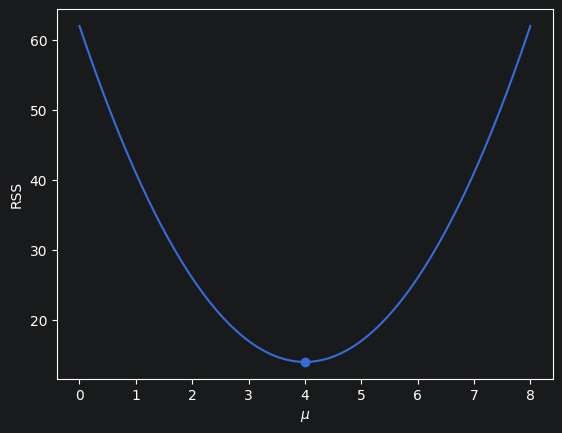

In [4]:
y = np.array([2.0, 3.0, 7.0])
mu_hat = y.mean()
mu = np.linspace(0, 8, 200)
rss = np.sum((y[:, None] - mu) ** 2, axis=0)

plt.plot(mu, rss)
plt.scatter([mu_hat], [np.sum((y - mu_hat) ** 2)])
plt.xlabel("$\\mu$")
plt.ylabel("RSS")
mu_hat


The other half of calculus in this course is a definite integral: $\int_a^b f(x)\,dx$ is the (signed) area under $f$ from $a$ to $b$. You do not need antiderivatives or the fundamental theorem on the midterm. You need to read the symbol as that area.

Week 3: a PDF $f$ is a curve whose total area is 1. Probability is a piece of that area,

$$
P(a\le X\le b)=\int_a^b f(x)\,dx.
$$

The CDF is the area from the left, $F(x)=\int_{-\infty}^x f(t)\,dt$, and $f=F'$.

Expected value is a weighted area. Discrete (weeks 1–2 and 7): $E[X]=\sum_x x\,P(X=x)$. Continuous:

$$
E[X]=\int x\,f(x)\,dx.
$$

Same idea: each $x$ weighted by how much probability sits there. Week 7 uses this for $E[U(a)]$. The next cell uses Uniform$(0,2)$, density $f=1/2$. The area is 1. $E[X]=1$. The discrete check is the three numbers from the parabola, equally likely; $E[X]$ is the sample mean you just marked.

- Video: [Introduction to integral calculus](https://www.khanacademy.org/math/ap-calculus-ab/ab-integration-new/ab-6-1/v/introduction-to-integral-calculus)
- Unit: [Calculus 1, integrals](https://www.khanacademy.org/math/calculus-1/cs1-integrals) (stop after definite integrals as area; skip volumes)
- Video: [Density curves](https://www.khanacademy.org/math/statistics-probability/modeling-distributions-of-data/density-curve/v/density-curves)
- Video: [Probability density functions](https://www.khanacademy.org/math/statistics-probability/random-variables-stats-library/random-variables-continuous/v/probability-density-functions)
- Video: [Expected value of a discrete random variable](https://www.khanacademy.org/math/ap-statistics/random-variables-ap/xfb5d8e68:mean-standard-deviation-random-variables/v/expected-value-of-a-discrete-random-variable)
- Video: [Interpreting expected value](https://www.khanacademy.org/math/ap-statistics/random-variables-ap/xfb5d8e68:mean-standard-deviation-random-variables/v/interpreting-expected-value)


(np.float64(0.9999999999999998),
 np.float64(1.0),
 np.float64(3.9999999999999996))

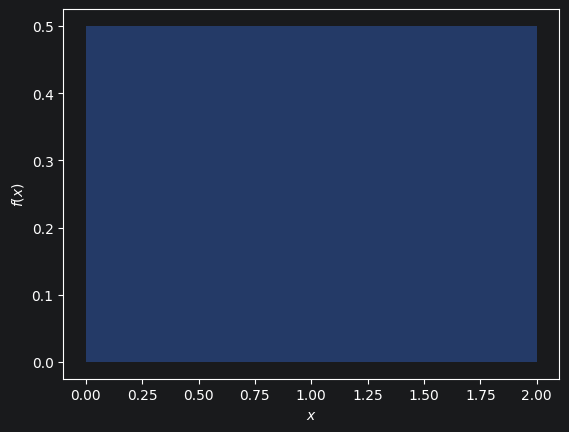

In [5]:
n = 400
dx = 2 / n
x_mid = np.linspace(dx / 2, 2 - dx / 2, n)
pdf = np.full_like(x_mid, 0.5)
area = np.sum(pdf * dx)
EX = np.sum(x_mid * pdf * dx)

x_plot = np.linspace(0, 2, 200)
plt.fill_between(x_plot, 0.5, alpha=0.4)
plt.xlabel("$x$")
plt.ylabel("$f(x)$")

ys = np.array([2.0, 3.0, 7.0])
area, EX, np.sum(ys * (1 / 3))


## 3. Chain rule, $\ln$, $e^x$. Log-odds and nesting

The two derivatives that show up in every log-likelihood:

$$
\frac{d}{dx}\ln x = \frac{1}{x},\qquad \frac{d}{dx}e^x = e^x
$$

The chain rule is how you differentiate a composition: $\frac{d}{dx}\ln g(x)=g'(x)/g(x)$. Bernoulli is the first place this matters. For one observation $y\in\{0,1\}$ with $P(Y=1)=p$,

$$
\ell(p)=y\ln p+(1-y)\ln(1-p).
$$

The payoff of the chain rule is the minus sign on the failure term: $\frac{d}{dp}\ln(1-p)=-1/(1-p)$. So

$$
\frac{d\ell}{dp}=\frac{y}{p}-\frac{1-y}{1-p}.
$$

With several observations you sum those scores. The next cell uses two successes and one failure. The MLE is $2/3$. The slope of $\ell(p)$ is positive below that, zero at it, and negative above it. The printed middle number will be on the order of $10^{-16}$, not a clean `0`. That is floating point; it is zero for our purposes.

Week 6 puts a line under $p$. Odds are $p/(1-p)$. Log-odds are $\ln(p/(1-p))$. The inverse of $\ln$ is $\exp$, so

$$
\ln\frac{p}{1-p}=\beta^\top x,\qquad
p=\frac{e^{\beta^\top x}}{1+e^{\beta^\top x}}.
$$

$\beta_j$ is the change in log-odds per unit of $x_j$. Log-odds $=0$ is the decision boundary: $p=1/2$. Week 7 and 9 sometimes write the complement $(1-p)/p$; that is the other way up, same pair of numbers.

A network is the same chain rule with more nests. $(f\circ g)(x)=f(g(x))$. Week 12 writes $F=f_L\circ\cdots\circ f_1$ and walks the derivative backwards through the layers. That is all backprop is.

- Video: [Chain rule introduction](https://www.khanacademy.org/math/calculus-home/taking-derivatives-calc/chain-rule-calc/v/chain-rule-introduction)
- Video: [Derivative of $\ln x$](https://www.khanacademy.org/math/ap-calculus-ab/ab-derivatives-advanced/ab-diff-log/v/derivative-of-lnx)
- Video: [Log functions, more practice](https://www.khanacademy.org/math/calculus-1/cs1-derivatives-chain-rule-and-other-advanced-topics/cs1-more-chain-rule-practice/v/log-functions-differentiation)
- Video: [Derivative of $e^x$](https://www.khanacademy.org/math/ap-calculus-ab/ab-differentiation-1-new/ab-2-7/v/derivative-of-ex)
- Video: [Evaluating composite functions](https://www.khanacademy.org/math/precalculus/x9e81a4f98389efdf:composite/x9e81a4f98389efdf:composing/v/evaluating-composite-functions)
- Unit: [Chain rule and advanced topics](https://www.khanacademy.org/math/calculus-1/cs1-derivatives-chain-rule-and-other-advanced-topics)


In [6]:
y = np.array([1.0, 1.0, 0.0])

def d_ell_dp(y, p):
    return np.sum(y / p - (1 - y) / (1 - p))

d_ell_dp(y, 0.4), d_ell_dp(y, 2 / 3), d_ell_dp(y, 0.8)


(np.float64(3.333333333333333),
 np.float64(4.440892098500626e-16),
 np.float64(-2.500000000000001))

In [7]:
def sigmoid(eta):
    return np.exp(eta) / (1 + np.exp(eta))

p = 0.8
eta = np.log(p / (1 - p))
eta, sigmoid(eta), sigmoid(0)


(np.float64(1.3862943611198908), np.float64(0.8), np.float64(0.5))

In [8]:
def relu(z):
    return np.maximum(z, 0)  # ReLU, week 12

def g(x):
    return 2 * x - 1

x = np.array([-1.0, 0.0, 1.0, 2.0])
relu(g(x))  # (relu ∘ g)(x)


array([0., 0., 1., 3.])

## 4. Partials and the gradient. Used for MLE and SGD

With two unknowns, differentiate one at a time. Those two numbers are the gradient,

$$
\nabla L = \left(\frac{\partial L}{\partial\theta_0},\frac{\partial L}{\partial\theta_1}\right).
$$

The gradient points uphill. Descent steps the other way:

$$
\theta \leftarrow \theta - \eta\,\nabla L.
$$

Full-batch gradient descent uses every row. SGD replaces $\nabla L$ by the gradient on one row, or a minibatch. Same background; the extra idea is the noisy step. Section 6 runs both.

- Video: [Partial derivatives](https://www.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/partial-derivatives/v/partial-derivatives-introduction)
- Video: [Partial derivatives and graphs](https://www.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/partial-derivatives/v/partial-derivatives-and-graphs)
- Article: [The gradient](https://www.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/partial-derivative-and-gradient-articles/a/the-gradient)
- Video: [Why the gradient is steepest ascent](https://www.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/gradient-and-directional-derivatives/v/why-the-gradient-is-the-direction-of-steepest-ascent)
- Unit: [Multivariable derivatives](https://www.khanacademy.org/math/multivariable-calculus/multivariable-derivatives). Stop after the gradient. You do not need divergence, curl, or integrals.

Three points, $(x,y)=(0,1)$, $(1,3)$, $(2,3)$. Intercept $a$, slope $b$. No line hits all three, so the loss is a compromise:

$$
L=(1-a)^2+(3-a-b)^2+(3-a-2b)^2.
$$

The cell evaluates $\nabla L$ at $(0,0)$ and takes one step downhill.


In [9]:
def L(a, b):
    return (1 - a) ** 2 + (3 - a - b) ** 2 + (3 - a - 2 * b) ** 2

def grad_L(a, b):
    r1, r2, r3 = 1 - a, 3 - a - b, 3 - a - 2 * b
    return np.array([-2 * r1 - 2 * r2 - 2 * r3, -2 * r2 - 4 * r3])

theta = np.array([0.0, 0.0])
eta = 0.05
g = grad_L(*theta)
theta_1 = theta - eta * g
L(*theta), g, L(*theta_1)


(np.float64(19.0), array([-14., -18.]), np.float64(2.3))

## 5. Vectors and matrices. Products, norms, ridge

A vector is a column of numbers. The intercept and slope sit in $\beta$. Two products do all of the arithmetic in OLS and in a network layer.

Matrix-vector: $(X\beta)_i$ is row $i$ of $X$ dotted with $\beta$. That is the fitted value for observation $i$. $X$ is $n\times p$, $\beta$ is $p\times 1$, $X\beta$ is $n\times 1$.

Matrix-matrix: $(AB)_{ij}$ is row $i$ of $A$ dotted with column $j$ of $B$. Inner dimensions must match. $X^\top X$ is $p\times p$: each entry is a dot product of two columns of $X$. A layer $W_\ell Z_\ell$ is the same product. Print `.shape` when a product fails.

The vector 2-norm is length: $\|v\|_2=\sqrt{\sum_j v_j^2}$, and $\|v\|_2^2=v^\top v$. Residual sum of squares is $\|y-X\beta\|_2^2$. The matrix analogue we use is Frobenius, the 2-norm of the entries:

$$
\|A\|_F=\sqrt{\sum_{i,j}A_{ij}^2}.
$$

$\|A\|_F^2$ is the ridge penalty when $A$ is a weight matrix. The bound $\|X\beta\|_2\le\|X\|_F\|\beta\|_2$ is why a large $X$ or a large $\beta$ can stretch fitted values. Skip the operator (spectral) norm; it needs eigenvalues.

Reading $\hat\beta=(X^\top X)^{-1}X^\top y$ left to right: transpose, matrix-matrix, invert, matrix-vector. Week 10 adds $\lambda I$ on the diagonal,

$$
\hat\beta_{\mathrm{ridge}}=(X^\top X+\lambda I)^{-1}X^\top y.
$$

- Video: [Vector introduction](https://www.khanacademy.org/math/linear-algebra/vectors-and-spaces/vectors/v/vector-introduction-linear-algebra)
- Video: [Dot product](https://www.khanacademy.org/math/linear-algebra/vectors-and-spaces/dot-cross-products/v/vector-dot-product-and-vector-length) (the length in this video is $\|v\|_2$)
- Video: [Matrix-vector products](https://www.khanacademy.org/math/linear-algebra/matrix-transformations/linear-transformations/v/linear-transformations-as-matrix-vector-products)
- Article: [Matrix multiplication dimensions](https://www.khanacademy.org/math/precalculus/x9e81a4f98389efdf:matrices/x9e81a4f98389efdf:properties-of-matrix-multiplication/a/matrix-multiplication-dimensions)
- Video: [Matrix multiplication intro](https://www.khanacademy.org/math/precalculus/precalc-matrices/matrix_multiplication/v/matrix-multiplication-intro)
- Exercise: [Multiplying a matrix by a matrix](https://www.khanacademy.org/math/precalculus/precalc-matrices/multiplying-matrices-by-matrices/e/multiplying_a_matrix_by_a_matrix)
- Video: [Defined and undefined matrix operations](https://www.khanacademy.org/math/precalculus/x9e81a4f98389efdf:matrices/x9e81a4f98389efdf:properties-of-matrix-multiplication/v/defined-and-undefined-matrix-operations)
- Article: [Introduction to the matrix](https://www.khanacademy.org/math/precalculus/x9e81a4f98389efdf:matrices/x9e81a4f98389efdf:mat-intro/a/intro-to-matrices)
- Video: [Inverse of a 2×2](https://www.khanacademy.org/math/precalculus/x9e81a4f98389efdf:matrices/x9e81a4f98389efdf:practice-finding-inverses-of-2x2-matrices/v/inverse-of-a-2x2-matrix)
- Video: [Transpose of a vector](https://www.khanacademy.org/math/linear-algebra/matrix-transformations/matrix-transpose/v/linear-algebra-transpose-of-a-vector)
- Video: [Transpose of a matrix](https://www.khanacademy.org/math/linear-algebra/matrix-transformations/matrix-transpose/v/linear-algebra-transpose-of-a-matrix)
- Unit, start here: [Precalculus, matrices](https://www.khanacademy.org/math/precalculus/x9e81a4f98389efdf:matrices)

The next cell does both products by hand, then checks them with `@`. Same three points after that for OLS. No line hits all three, so the residuals are not zero.


In [10]:
X = np.array([[1.0, 0.0],
              [1.0, 1.0],
              [1.0, 2.0]])
beta = np.array([1.0, 2.0])

# matrix-vector: each fitted value is a row of X dotted with beta
fitted_hand = np.array([X[0] @ beta, X[1] @ beta, X[2] @ beta])
fitted = X @ beta

# matrix-matrix: (X.T @ X)_{jk} is column j of X dotted with column k
XtX_hand = np.array([
    [X[:, 0] @ X[:, 0], X[:, 0] @ X[:, 1]],
    [X[:, 1] @ X[:, 0], X[:, 1] @ X[:, 1]],
])
XtX = X.T @ X

# vector 2-norm and Frobenius (2-norm of the entries)
beta_norm = np.sqrt(beta @ beta)
X_F = np.sqrt(np.sum(X ** 2))

fitted_hand, fitted, XtX_hand, XtX, beta_norm, X_F, np.linalg.norm(fitted) <= X_F * beta_norm


(array([1., 3., 5.]),
 array([1., 3., 5.]),
 array([[3., 3.],
        [3., 5.]]),
 array([[3., 3.],
        [3., 5.]]),
 np.float64(2.23606797749979),
 np.float64(2.8284271247461903),
 np.True_)

In [11]:
y = np.array([1.0, 3.0, 3.0])
beta_formula = np.linalg.inv(X.T @ X) @ X.T @ y
beta_hat = np.linalg.solve(X.T @ X, X.T @ y)  # stable way to apply the inverse
resid = y - X @ beta_hat
lam = 1.0
beta_ridge = np.linalg.solve(X.T @ X + lam * np.eye(X.shape[1]), X.T @ y)
rss = resid @ resid
(X.shape, y.shape, beta_hat.shape, (X @ beta_hat).shape, (X.T @ X).shape,
 beta_formula, beta_hat, resid, rss, np.linalg.norm(resid), np.linalg.norm(X, "fro"), beta_ridge)


((3, 2),
 (3,),
 (2,),
 (3,),
 (2, 2),
 array([1.3333, 1.    ]),
 array([1.3333, 1.    ]),
 array([-0.3333,  0.6667, -0.3333]),
 np.float64(0.6666666666666669),
 np.float64(0.8164965809277261),
 np.float64(2.8284271247461903),
 array([1., 1.]))

## 6. The three methods on the same numbers

For a normal linear model, MLE and OLS are the same $\hat\beta$. Gradient descent is an iterative way to the same place. It will not land on the closed form in a few dozen steps; that is the point of an iterative method. The first loop is full-batch and uses the update from §4: $\theta\leftarrow\theta-\eta\nabla L$, with $\nabla L$ the gradient of the residual sum of squares. The second loop is SGD: the same update, one row at a time, with a decaying step $\eta_k=0.1/\sqrt{k+1}$. A constant step does not land on the closed form. It rattles around it, which is why the step decays (the idea behind Robbins–Monro, week 12).

If this cell is readable, you have the background. Week 4 writes a log-likelihood instead of RSS. Week 12 is this one-row update inside a composition of layers.


In [12]:
eta = 0.1
beta = np.array([0.0, 0.0])
path = [beta.copy()]
for _ in range(80):
    grad = -2 * X.T @ (y - X @ beta)  # gradient of RSS
    beta = beta - eta * grad            # theta <- theta - eta * grad
    path.append(beta.copy())

beta_sgd = np.array([0.0, 0.0])
for k in range(80):
    eta_k = 0.1 / np.sqrt(k + 1)
    for i in range(len(y)):
        resid_i = y[i] - X[i] @ beta_sgd
        grad_i = -2 * resid_i * X[i]
        beta_sgd = beta_sgd - eta_k * grad_i

np.vstack(path[::20]), beta, beta_sgd, beta_hat


(array([[0.    , 0.    ],
        [1.323 , 1.0074],
        [1.3331, 1.0002],
        [1.3333, 1.    ],
        [1.3333, 1.    ]]),
 array([1.3333, 1.    ]),
 array([1.3344, 0.9858]),
 array([1.3333, 1.    ]))

## Done when

You can say, without the notebook, what each symbol is doing in $\hat\beta=(X^\top X)^{-1}X^\top y$, how a matrix-vector product differs from a matrix-matrix product, what $\|A\|_F$ adds up, why $\ln$ appears in a likelihood, why a log-log slope is a percent per percent, why log-odds $=0$ means $p=1/2$, why $(f\circ g)(x)=f(g(x))$, why $E[X]$ is an area when $X$ is continuous, and why SGD subtracts the gradient rather than adding it.

If a later note uses a derivative or a matrix you do not recognize, ask the [course tutor](https://vsokolov.org/courses/600.html#course-tutor). Point it at this notebook and the note.
